In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas_datareader.data as web
import datetime

from functions import get_polymarket_event, lead_lag_correlation, bootstrap_significance

In [2]:
april_event, april_probs = get_polymarket_event("fed-decision-in-april", "2026-04-29")
for name, df in april_probs.items():
    print(name, len(df), "points")

50+ bps decrease 240 points
25 bps decrease 240 points
No change 240 points
25+ bps increase 240 points


In [3]:
start_april = datetime.datetime(2026, 3, 29)
end_april = datetime.datetime(2026, 4, 28)

effr_april = web.DataReader('EFFR', 'fred', start_april, end_april)
r_before_april = effr_april['EFFR'].mean()
print(r_before_april)

3.64


In [4]:
combined_april = pd.DataFrame()
for outcome_name, odf in april_probs.items():
    s = odf.set_index('datetime')['p'].resample('1min').last().ffill()
    combined_april[outcome_name] = s

combined_april = combined_april.dropna()
print(combined_april.head())
print(combined_april.tail())

                           50+ bps decrease  25 bps decrease  No change  \
datetime                                                                  
2026-04-29 12:00:00-04:00            0.0005           0.0015     0.9975   
2026-04-29 12:01:00-04:00            0.0005           0.0015     0.9975   
2026-04-29 12:02:00-04:00            0.0005           0.0015     0.9975   
2026-04-29 12:03:00-04:00            0.0005           0.0015     0.9975   
2026-04-29 12:04:00-04:00            0.0005           0.0020     0.9975   

                           25+ bps increase  
datetime                                     
2026-04-29 12:00:00-04:00            0.0005  
2026-04-29 12:01:00-04:00            0.0005  
2026-04-29 12:02:00-04:00            0.0005  
2026-04-29 12:03:00-04:00            0.0005  
2026-04-29 12:04:00-04:00            0.0005  
                           50+ bps decrease  25 bps decrease  No change  \
datetime                                                                  
20

In [5]:
prob_sum_april = (
    combined_april['50+ bps decrease'] +
    combined_april['25 bps decrease'] +
    combined_april['No change'] +
    combined_april['25+ bps increase']
)

combined_april['r_after'] = (
    (combined_april['50+ bps decrease'] / prob_sum_april) * (r_before_april - 0.50) +
    (combined_april['25 bps decrease'] / prob_sum_april) * (r_before_april - 0.25) +
    (combined_april['No change'] / prob_sum_april) * r_before_april +
    (combined_april['25+ bps increase'] / prob_sum_april) * (r_before_april + 0.25)
)

print(combined_april[['r_after']].head())
print(combined_april[['r_after']].tail())

                            r_after
datetime                           
2026-04-29 12:00:00-04:00  3.639500
2026-04-29 12:01:00-04:00  3.639500
2026-04-29 12:02:00-04:00  3.639500
2026-04-29 12:03:00-04:00  3.639500
2026-04-29 12:04:00-04:00  3.639375
                           r_after
datetime                          
2026-04-29 15:55:00-04:00  3.63975
2026-04-29 15:56:00-04:00  3.63975
2026-04-29 15:57:00-04:00  3.63975
2026-04-29 15:58:00-04:00  3.63975
2026-04-29 15:59:00-04:00  3.63975


In [6]:
zq_2026 = pd.read_csv('zq_2026.csv')
zq_2026['datetime'] = pd.to_datetime(zq_2026['time'], unit='s')
zq_2026['datetime'] = zq_2026['datetime'].dt.tz_localize('UTC').dt.tz_convert('America/New_York')

april_zq_window = zq_2026[(zq_2026['datetime'] >= '2026-04-29 12:00:00') & (zq_2026['datetime'] <= '2026-04-29 16:00:00')].copy()
april_zq_window['implied_rate'] = 100 - april_zq_window['close']
print(april_zq_window.head())
print(april_zq_window.tail())

            time     open     high      low    close  Volume  \
6404  1777478520  96.3575  96.3575  96.3575  96.3575      50   
6405  1777478580  96.3600  96.3600  96.3575  96.3575      71   
6406  1777478640  96.3600  96.3600  96.3600  96.3600      10   
6407  1777479060  96.3600  96.3600  96.3600  96.3600       1   
6408  1777479600  96.3600  96.3600  96.3600  96.3600       1   

                      datetime  implied_rate  
6404 2026-04-29 12:02:00-04:00        3.6425  
6405 2026-04-29 12:03:00-04:00        3.6425  
6406 2026-04-29 12:04:00-04:00        3.6400  
6407 2026-04-29 12:11:00-04:00        3.6400  
6408 2026-04-29 12:20:00-04:00        3.6400  
            time     open     high      low    close  Volume  \
6445  1777489140  96.3600  96.3600  96.3600  96.3600      10   
6446  1777490280  96.3575  96.3575  96.3575  96.3575    2000   
6447  1777492080  96.3575  96.3575  96.3575  96.3575       3   
6448  1777492140  96.3575  96.3575  96.3575  96.3575       2   
6449  1777492

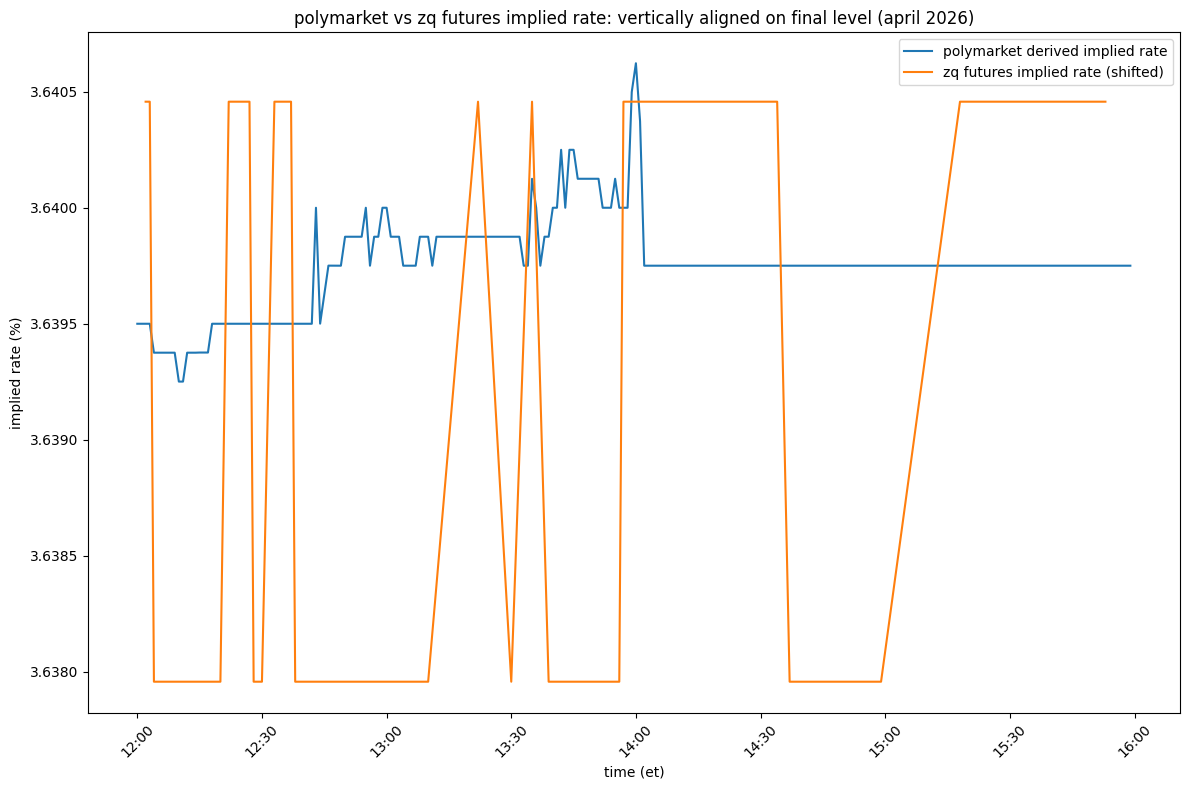

In [7]:
zq_final_april = april_zq_window[april_zq_window['datetime'] >= '2026-04-29 14:00:00']['implied_rate'].mean()
poly_final_april = combined_april[combined_april.index >= '2026-04-29 14:00:00']['r_after'].mean()
shift_april = poly_final_april - zq_final_april
april_zq_window['implied_rate_shifted'] = april_zq_window['implied_rate'] + shift_april

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined_april.index, combined_april['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(april_zq_window['datetime'], april_zq_window['implied_rate_shifted'], label='zq futures implied rate (shifted)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: vertically aligned on final level (april 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=april_zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

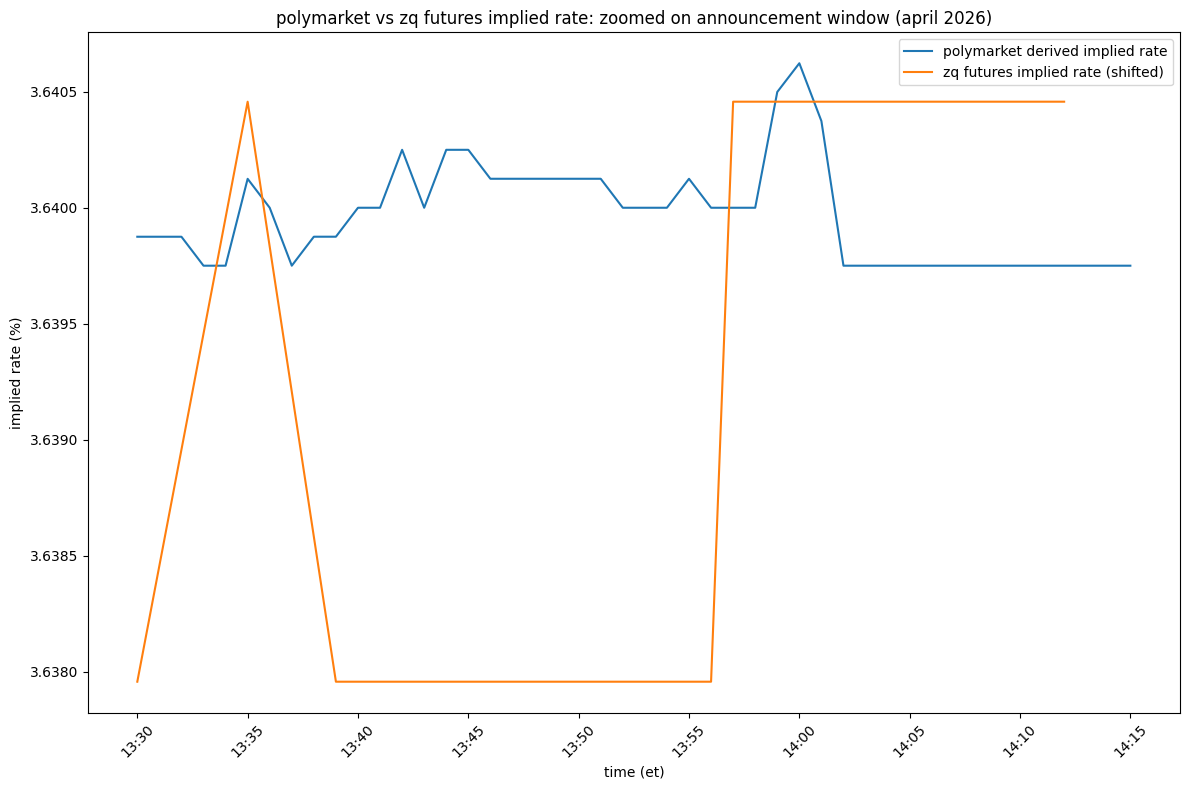

In [8]:
zoom_start_april = '2026-04-29 13:30:00'
zoom_end_april = '2026-04-29 14:15:00'

combined_zoom_april = combined_april[(combined_april.index >= zoom_start_april) & (combined_april.index <= zoom_end_april)]
zq_zoom_april = april_zq_window[(april_zq_window['datetime'] >= zoom_start_april) & (april_zq_window['datetime'] <= zoom_end_april)]

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(combined_zoom_april.index, combined_zoom_april['r_after'], label='polymarket derived implied rate', color='tab:blue')
ax.plot(zq_zoom_april['datetime'], zq_zoom_april['implied_rate_shifted'], label='zq futures implied rate (shifted)', color='tab:orange')
ax.set_title('polymarket vs zq futures implied rate: zoomed on announcement window (april 2026)')
ax.set_xlabel('time (et)')
ax.set_ylabel('implied rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=april_zq_window['datetime'].dt.tz))
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
pre_window_april = combined_april[(combined_april.index >= '2026-04-29 13:40:00') & (combined_april.index <= '2026-04-29 13:58:00')]
poly_diff_pre_april = pre_window_april['r_after'].diff()

zq_pre_april = april_zq_window[(april_zq_window['datetime'] >= '2026-04-29 13:40:00') & (april_zq_window['datetime'] <= '2026-04-29 13:58:00')]
zq_diff_pre_april = zq_pre_april.set_index('datetime')['implied_rate'].diff()

print("polymarket real moves:")
print(poly_diff_pre_april[poly_diff_pre_april != 0].dropna())
print("\nzq real moves:")
print(zq_diff_pre_april[zq_diff_pre_april != 0].dropna())

polymarket real moves:
datetime
2026-04-29 13:42:00-04:00    0.000250
2026-04-29 13:43:00-04:00   -0.000250
2026-04-29 13:44:00-04:00    0.000250
2026-04-29 13:46:00-04:00   -0.000125
2026-04-29 13:52:00-04:00   -0.000125
2026-04-29 13:55:00-04:00    0.000125
2026-04-29 13:56:00-04:00   -0.000125
Name: r_after, dtype: float64

zq real moves:
datetime
2026-04-29 13:57:00-04:00    0.0025
Name: implied_rate, dtype: float64


In [10]:
window_x = combined_april[(combined_april.index >= '2026-04-29 13:30:00') & (combined_april.index <= '2026-04-29 14:30:00')]['r_after']
window_y = april_zq_window.set_index('datetime')['implied_rate']
window_y = window_y[(window_y.index >= '2026-04-29 13:30:00') & (window_y.index <= '2026-04-29 14:30:00')]

lags_df, best_lag, best_corr = lead_lag_correlation(window_x, window_y, max_lag_minutes=30)
print(f"best_lag: {best_lag}, best_corr: {best_corr:.3f}")
print(lags_df.sort_values('correlation', ascending=False).head())

best_lag: -6, best_corr: 0.895
    lag  correlation  n_obs
0    -6     0.895115      9
14    8     0.547723      7
6     0     0.507304     15
10    4     0.416779     11
8     2     0.412007     13


In [11]:
lags_df, best_lag, best_corr = lead_lag_correlation(window_x, window_y, max_lag_minutes=30)
p_value = bootstrap_significance(window_x, window_y, observed_corr=best_corr, max_lag_minutes=30)
print(f"best lag: {best_lag}, best correlation: {best_corr:.3f}, p-value: {p_value:.3f}")

best lag: -6, best correlation: 0.895, p-value: 0.111
